In [1]:
import pandas as pd

In [2]:
# 1.Load the dataset and display the number of missing values per column.
df = pd.read_csv(r"C:\Users\XNovaQ.16\Downloads\student_info.csv")
df

,Student_ID,Name,Department,Marks_Math,Marks_English,Marks_Science,Attendance
0,1001,Ganesh,CSE,72.0,87.0,59.0,94.0
1,1002,Divya,EEE,79.0,40.0,48.0,91.0
2,1003,Karthik,CSE,78.0,69.0,46.0,88.0
3,1004,Hema,EEE,57.0,94.0,92.0,63.0
4,1005,Ekansh,ECE,79.0,75.0,48.0,80.0
...,...,...,...,...,...,...,...
115,1116,Karthik,MECH,83.0,50.0,82.0,77.0
116,1117,Ekansh,MECH,NaN,47.0,52.0,86.0
117,1118,Jothi,EEE,69.0,84.0,45.0,90.0
118,1119,Ganesh,EEE,68.0,NaN,86.0,85.0


In [8]:
missing_count = df.isna().sum()
print("Number of missing columns:\n",missing_count)

Number of missing columns:
 Student_ID        0
Name              0
Department        0
Marks_Math       12
Marks_English    12
Marks_Science    12
Attendance       12
dtype: int64


In [9]:
# 2. Remove rows where more than 2 columns have null values.
df_cleaned = df[df.isnull().sum(axis=1) <= 2]
print("After removing rows with more than 2 NaNs:\n", df_cleaned)

After removing rows with more than 2 NaNs:
      Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
0          1001   Ganesh        CSE        72.0           87.0           59.0   
1          1002    Divya        EEE        79.0           40.0           48.0   
2          1003  Karthik        CSE        78.0           69.0           46.0   
3          1004     Hema        EEE        57.0           94.0           92.0   
4          1005   Ekansh        ECE        79.0           75.0           48.0   
..          ...      ...        ...         ...            ...            ...   
115        1116  Karthik       MECH        83.0           50.0           82.0   
116        1117   Ekansh       MECH         NaN           47.0           52.0   
117        1118    Jothi        EEE        69.0           84.0           45.0   
118        1119   Ganesh        EEE        68.0            NaN           86.0   
119        1120    Jothi        CSE        85.0           76.0   

In [13]:
# 3. Impute missing marks using: Mean for Math, Median for English, Mode for Science
df['Marks_Math'].fillna(df['Marks_Math'].mean(), inplace=True)          
df['Marks_English'].fillna(df['Marks_English'].median(), inplace=True)  
df['Marks_Science'].fillna(df['Marks_Science'].mode()[0], inplace=True) 
print(df)

     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
0          1001   Ganesh        CSE   72.000000           87.0           59.0   
1          1002    Divya        EEE   79.000000           40.0           48.0   
2          1003  Karthik        CSE   78.000000           69.0           46.0   
3          1004     Hema        EEE   57.000000           94.0           92.0   
4          1005   Ekansh        ECE   79.000000           75.0           48.0   
..          ...      ...        ...         ...            ...            ...   
115        1116  Karthik       MECH   83.000000           50.0           82.0   
116        1117   Ekansh       MECH   70.962963           47.0           52.0   
117        1118    Jothi        EEE   69.000000           84.0           45.0   
118        1119   Ganesh        EEE   68.000000           69.0           86.0   
119        1120    Jothi        CSE   85.000000           76.0           68.0   

     Attendance  
0        

C:\Users\XNovaQ.16\AppData\Local\Temp\ipykernel_17048\1936747713.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marks_Math'].fillna(df['Marks_Math'].mean(), inplace=True)
C:\Users\XNovaQ.16\AppData\Local\Temp\ipykernel_17048\1936747713.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [15]:
# 4. Create a new column Total_Marks (sum of Math, English, Science).
df['Total_Marks'] = df[['Marks_Math', 'Marks_English', 'Marks_Science']].sum(axis=1)
print(df)


     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
0          1001   Ganesh        CSE   72.000000           87.0           59.0   
1          1002    Divya        EEE   79.000000           40.0           48.0   
2          1003  Karthik        CSE   78.000000           69.0           46.0   
3          1004     Hema        EEE   57.000000           94.0           92.0   
4          1005   Ekansh        ECE   79.000000           75.0           48.0   
..          ...      ...        ...         ...            ...            ...   
115        1116  Karthik       MECH   83.000000           50.0           82.0   
116        1117   Ekansh       MECH   70.962963           47.0           52.0   
117        1118    Jothi        EEE   69.000000           84.0           45.0   
118        1119   Ganesh        EEE   68.000000           69.0           86.0   
119        1120    Jothi        CSE   85.000000           76.0           68.0   

     Attendance  Total_Mark

In [17]:
# 5. Create a new column Performance_Level: "High" if Total_Marks ≥ 240, "Medium" if 180–239, "Low" otherwise
def performance_level(total):
    if total >= 240:
        return 'High'
    elif 180 <= total < 240:
        return 'Medium'
    else:
        return 'Low'
df['Performance_Level'] = df['Total_Marks'].apply(performance_level)
print(df)

     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
0          1001   Ganesh        CSE   72.000000           87.0           59.0   
1          1002    Divya        EEE   79.000000           40.0           48.0   
2          1003  Karthik        CSE   78.000000           69.0           46.0   
3          1004     Hema        EEE   57.000000           94.0           92.0   
4          1005   Ekansh        ECE   79.000000           75.0           48.0   
..          ...      ...        ...         ...            ...            ...   
115        1116  Karthik       MECH   83.000000           50.0           82.0   
116        1117   Ekansh       MECH   70.962963           47.0           52.0   
117        1118    Jothi        EEE   69.000000           84.0           45.0   
118        1119   Ganesh        EEE   68.000000           69.0           86.0   
119        1120    Jothi        CSE   85.000000           76.0           68.0   

     Attendance  Total_Mark

In [32]:
# 6. Find the top 5 students in each department based on Total_Marks.
top5 = df.sort_values("Total_Marks", ascending=False).groupby("Department").head(5)
print(top5)

     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
23         1024  Bhuvana      CIVIL   99.000000           76.0           96.0   
32         1033     Arun      CIVIL   98.000000           66.0           98.0   
94         1095   Ishaan        ECE   84.000000           94.0           84.0   
58         1059   Ekansh      CIVIL   74.000000           94.0           90.0   
86         1087    Latha        EEE   90.000000           69.0           93.0   
62         1063    Latha        CSE   85.000000           70.0           96.0   
99         1100     Arun      CIVIL   66.000000           94.0           91.0   
46         1047   Ganesh        EEE   63.000000           88.0           98.0   
31         1032   Ishaan       MECH   71.000000           84.0           91.0   
21         1022    Latha        ECE   96.000000           52.0           98.0   
88         1089     Hema        CSE   94.000000           86.0           65.0   
85         1086   Ganesh    

In [33]:
# 7. Find departments where average attendance < 75%.
low_attendance = df.groupby("Department")["Attendance"].mean()
low_attendance = low_attendance[low_attendance < 75]
print(low_attendance)

Department
CIVIL    74.533333
CSE      74.000000
ECE      71.846154
Name: Attendance, dtype: float64


In [35]:
# 8. Calculate department-wise correlation between Math, English, and Science scores.
dept_corr = df.groupby("Department")[["Marks_Math", "Marks_English", "Marks_Science"]].corr()
print(dept_corr)

                          Marks_Math  Marks_English  Marks_Science
Department                                                        
CIVIL      Marks_Math       1.000000       0.003511       0.176085
           Marks_English    0.003511       1.000000       0.126316
           Marks_Science    0.176085       0.126316       1.000000
CSE        Marks_Math       1.000000      -0.020197      -0.036277
           Marks_English   -0.020197       1.000000       0.017097
           Marks_Science   -0.036277       0.017097       1.000000
ECE        Marks_Math       1.000000       0.064600      -0.124965
           Marks_English    0.064600       1.000000      -0.481177
           Marks_Science   -0.124965      -0.481177       1.000000
EEE        Marks_Math       1.000000      -0.400737      -0.074881
           Marks_English   -0.400737       1.000000      -0.080744
           Marks_Science   -0.074881      -0.080744       1.000000
MECH       Marks_Math       1.000000      -0.052602      -0.21

In [38]:
# 9. Identify students who scored above 90 in any subject using filtering + any(axis=1).
high_scorers = df[ df[["Marks_Math","Marks_English","Marks_Science"]].gt(90).any(axis=1)]
print(high_scorers)

     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
3          1004     Hema        EEE        57.0           94.0           92.0   
7          1008  Charles       MECH        67.0           63.0           91.0   
13         1014    Divya      CIVIL        69.0           94.0           30.0   
17         1018    Farah        ECE        99.0           66.0           45.0   
19         1020  Bhuvana        CSE        65.0           67.0           93.0   
20         1021     Hema        ECE        87.0           37.0           92.0   
21         1022    Latha        ECE        96.0           52.0           98.0   
22         1023    Farah        EEE        91.0           59.0           51.0   
23         1024  Bhuvana      CIVIL        99.0           76.0           96.0   
26         1027     Arun        EEE        40.0           92.0           80.0   
29         1030    Farah      CIVIL        44.0           80.0           98.0   
31         1032   Ishaan    

In [41]:
# 10. Detect outliers in Science marks using the IQR method.
Q1 = df["Marks_Science"].quantile(0.25)
Q3 = df["Marks_Science"].quantile(0.75)
IQR = Q3 - Q1
science_outliers = df[(df["Marks_Science"] < (Q1 - 1.5*IQR)) | (df["Marks_Science"] > (Q3 + 1.5*IQR))]
print(science_outliers)

Empty DataFrame
Columns: [Student_ID, Name, Department, Marks_Math, Marks_English, Marks_Science, Attendance, Total_Marks, Performance_Level]
Index: []


In [43]:
# 11. Create a pivot table showing max, min, mean of all 3 subjects for each department.
pivot = df.pivot_table(values=["Marks_Math","Marks_English","Marks_Science"],
                       index="Department",
                       aggfunc=["max","min","mean"])
print(pivot)

                     max                                    min             \
           Marks_English Marks_Math Marks_Science Marks_English Marks_Math   
Department                                                                   
CIVIL               94.0       99.0          98.0          37.0       44.0   
CSE                 92.0       94.0          97.0          38.0       40.0   
ECE                 94.0       99.0          98.0          36.0       51.0   
EEE                 94.0       95.0          98.0          40.0       40.0   
MECH                92.0       99.0          98.0          35.0       43.0   

                                  mean                           
           Marks_Science Marks_English Marks_Math Marks_Science  
Department                                                       
CIVIL               30.0     70.777778  67.993827     69.777778  
CSE                 30.0     70.827586  66.618135     59.068966  
ECE                 39.0     66.000000  75.37

In [50]:
# 12. Replace null values in Attendance with random values (50–90).
import numpy as np
mask = df["Attendance"].isna()
df.loc[mask, "Attendance"] = np.random.randint(50, 91, mask.sum())

In [48]:
# 13. Sort students by: Department, Descending Total_Marks
sorted_df = df.sort_values(["Department","Total_Marks"], ascending=[True, False])
print(sorted_df)

     Student_ID     Name Department  Marks_Math  Marks_English  Marks_Science  \
23         1024  Bhuvana      CIVIL   99.000000           76.0           96.0   
32         1033     Arun      CIVIL   98.000000           66.0           98.0   
58         1059   Ekansh      CIVIL   74.000000           94.0           90.0   
99         1100     Arun      CIVIL   66.000000           94.0           91.0   
92         1093     Hema      CIVIL   77.000000           88.0           66.0   
..          ...      ...        ...         ...            ...            ...   
36         1037    Latha       MECH   74.000000           36.0           62.0   
116        1117   Ekansh       MECH   70.962963           47.0           52.0   
48         1049   Ishaan       MECH   50.000000           73.0           45.0   
102        1103   Ishaan       MECH   69.000000           39.0           48.0   
97         1098    Latha       MECH   47.000000           42.0           59.0   

     Attendance  Total_Mark

In [51]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 12.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 13.7 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------- -------------------- 3.4/7.0 MB 17.4 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 14.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   --

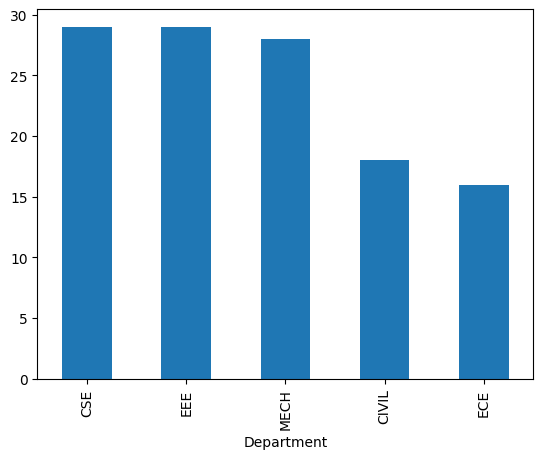

In [55]:
# 14. Plot (students count vs. department) using Pandas.
import matplotlib.pyplot as plt
df["Department"].value_counts().plot(kind="bar")
plt.show()

In [53]:
# 15. Export the cleaned DataFrame to a new CSV named student_file.csv
exported_data = df.to_csv("student_file.csv", index=False)
print(exported_data)

None
